#Akademik Başarı Tahmini – IST439 Makine Öğrenmesi Dönem Projesi
**Hazırlayan:** 2210329050 Ecemsu Arslan  
**Ders Sorumlusu:** Doç. Dr. Duygu İçen  
**Dönem:** 2025–2026 Bahar  

**Veri Seti:** Predicting Students' Dropout and Academic Success  
**Kaynak:** UCI Machine Learning Repository  
**Hedef:** Öğrencilerin `Dropout`, `Enrolled` veya `Graduate` durumunu tahmin etmek

##Kütüphaneler ve Ayarlar

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

# Görsel ayarlar
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('viridis')


##Veri Yükleme ve Ön İşleme
 Bazı sayısal sütunlar Excel'in Türkçe tarih formatına dönüştürmesinden kaynaklanan bozuk değerler içermektedir ( 10.Ağu  10.8 olarak yazılmıştır.). Bu değerler aşağıda düzeltilmiştir.

In [4]:
# ── Veri Yükleme ──────────────────────────────────────────────────────
df = pd.read_csv('dropout.csv', sep=';')
df.columns = df.columns.str.strip()  # sütun isimlerindeki boşlukları temizle

print(f"Veri boyutu: {df.shape[0]} gözlem × {df.shape[1]} değişken")
print("\nSütun isimleri:")
print(df.columns.tolist())

Veri boyutu: 4424 gözlem × 37 değişken

Sütun isimleri:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment

In [5]:
month_map = {
    'Oca':'1', 'Şub':'2', 'Mar':'3', 'Nis':'4', 'May':'5', 'Haz':'6',
    'Tem':'7', 'Ağu':'8', 'Eyl':'9', 'Eki':'10', 'Kas':'11', 'Ara':'12'
}

def fix_excel_val(val):
    if not isinstance(val, str):
        try:
            return float(val)
        except:
            return np.nan

    s = val.strip()

    # Ay ismi varsa değiştir
    for tr_ay, sayi in month_map.items():
        if tr_ay in s:
            s = s.replace(tr_ay, sayi)

    # Birden fazla nokta varsa ilk noktadan böl

    nokta_sayisi = s.count('.')
    if nokta_sayisi > 1:
        parcalar = s.split('.')
        s = parcalar[0] + '.' + parcalar[1]  # sadece ilk iki parçayı al

    try:
        return float(s.replace(',', '.'))
    except:
        return np.nan

bozuk_sutunlar = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate', 'GDP']

In [6]:
# ── Eksik Değer Analizi ───────────────────────────────────────────────
print("Eksik Değer Analizi:")
missing_total = df.isnull().sum().sum()
print(f"Toplam eksik değer: {missing_total}")
if missing_total > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])

Eksik Değer Analizi:
Toplam eksik değer: 0


In [7]:
# ── Hedef Değişkeni Kodlama ───────────────────────────────────────────
df['Target'] = df['Target'].str.strip()
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target'] = df['Target'].map(target_map)

if df['Target'].isnull().any():
    n_drop = df['Target'].isnull().sum()
    print(f"Uyarı: {n_drop} satır hedef değer eşleşmediği için çıkarıldı.")
    df = df.dropna(subset=['Target'])

df['Target'] = df['Target'].astype(int)

print("Hedef Değişken Dağılımı:")
sinif_isimleri = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
for kod, ad in sinif_isimleri.items():
    n = (df['Target'] == kod).sum()
    print(f"  {ad} ({kod}): {n} ({n/len(df)*100:.1f}%)")

Hedef Değişken Dağılımı:
  Dropout (0): 1421 (32.1%)
  Enrolled (1): 794 (17.9%)
  Graduate (2): 2209 (49.9%)


In [8]:
# ── Gereksiz Değişkenlerin Çıkarılması
# Neredeyse tüm öğrencilerde aynı değere sahip
cikart_listesi = [
    'Nacionality',
    'International',
    'Educational special needs',
    # Muaf sayılan ve sınavsız geçilen dersler – doğrudan başarı bilgisi vermiyor
    'Curricular units 1st sem (credited)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (without evaluations)',
    # Kayıt sayısı: approved/grade ile yüksek korelasyonlu (çoklu doğrusallık)
    'Curricular units 1st sem (enrolled)',
    'Curricular units 2nd sem (enrolled)',
]

df_temiz = df.drop(columns=cikart_listesi)
df_temiz = df_temiz.fillna(df_temiz.mean(numeric_only=True))

print(f"Orijinal değişken sayısı : {df.shape[1]}")
print(f"Temizlenmiş değişken sayısı: {df_temiz.shape[1]}")
print(f"\nKalan sütunlar ({df_temiz.shape[1]} adet):")
for c in df_temiz.columns:
    print(f"  • {c}")

Orijinal değişken sayısı : 37
Temizlenmiş değişken sayısı: 28

Kalan sütunlar (28 adet):
  • Marital status
  • Application mode
  • Application order
  • Course
  • Daytime/evening attendance
  • Previous qualification
  • Previous qualification (grade)
  • Mother's qualification
  • Father's qualification
  • Mother's occupation
  • Father's occupation
  • Admission grade
  • Displaced
  • Debtor
  • Tuition fees up to date
  • Gender
  • Scholarship holder
  • Age at enrollment
  • Curricular units 1st sem (evaluations)
  • Curricular units 1st sem (approved)
  • Curricular units 1st sem (grade)
  • Curricular units 2nd sem (evaluations)
  • Curricular units 2nd sem (approved)
  • Curricular units 2nd sem (grade)
  • Unemployment rate
  • Inflation rate
  • GDP
  • Target


##Keşifsel Veri Analizi (EDA)

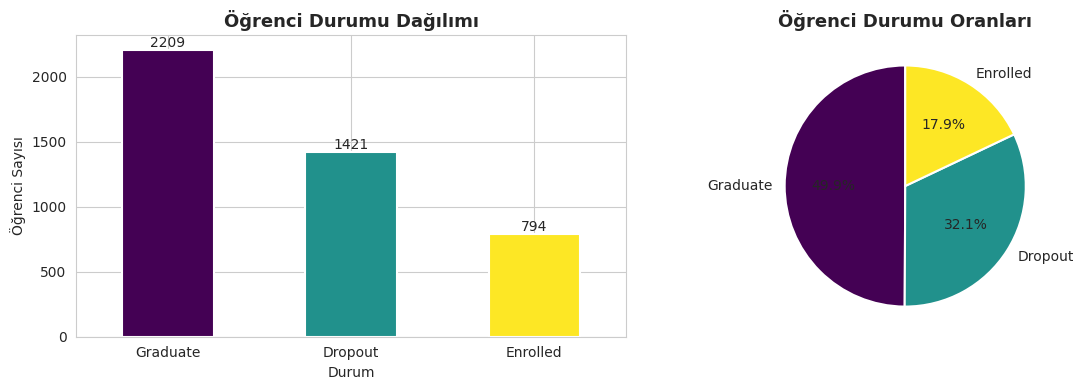

In [9]:
# ── Hedef Değişken Dağılımı ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar grafik
durum_sayilari = df_temiz['Target'].value_counts().rename({0:'Dropout',1:'Enrolled',2:'Graduate'})
durum_sayilari.plot(kind='bar', ax=axes[0], color=['#440154','#21918c','#fde725'],
                    edgecolor='white', linewidth=1.5)
axes[0].set_title('Öğrenci Durumu Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Durum')
axes[0].set_ylabel('Öğrenci Sayısı')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pasta grafik
axes[1].pie(durum_sayilari, labels=durum_sayilari.index, autopct='%1.1f%%',
            colors=['#440154','#21918c','#fde725'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Öğrenci Durumu Oranları', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

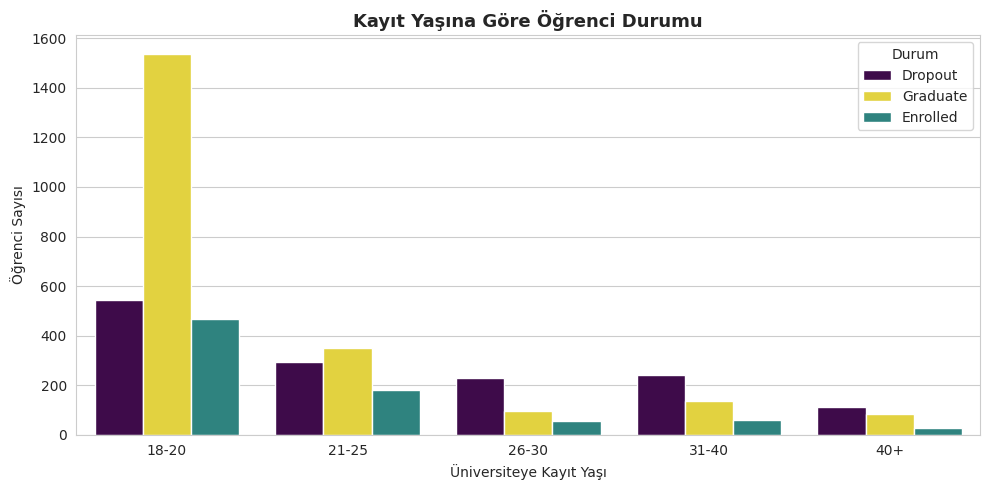

In [10]:
# ── Yaş ve Durum İlişkisi ─────────────────────────────────────────────
df_yas = df_temiz.copy()
df_yas['Durum'] = df_yas['Target'].map({0:'Dropout', 1:'Enrolled', 2:'Graduate'})
df_yas['Yas_Grubu'] = pd.cut(df_yas['Age at enrollment'],
                              bins=[17,20,25,30,40,70],
                              labels=['18-20','21-25','26-30','31-40','40+'])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_yas, x='Yas_Grubu', hue='Durum',
              palette={'Dropout':'#440154','Enrolled':'#21918c','Graduate':'#fde725'})
plt.title('Kayıt Yaşına Göre Öğrenci Durumu', fontsize=13, fontweight='bold')
plt.xlabel('Üniversiteye Kayıt Yaşı')
plt.ylabel('Öğrenci Sayısı')
plt.legend(title='Durum')
plt.tight_layout()
plt.show()

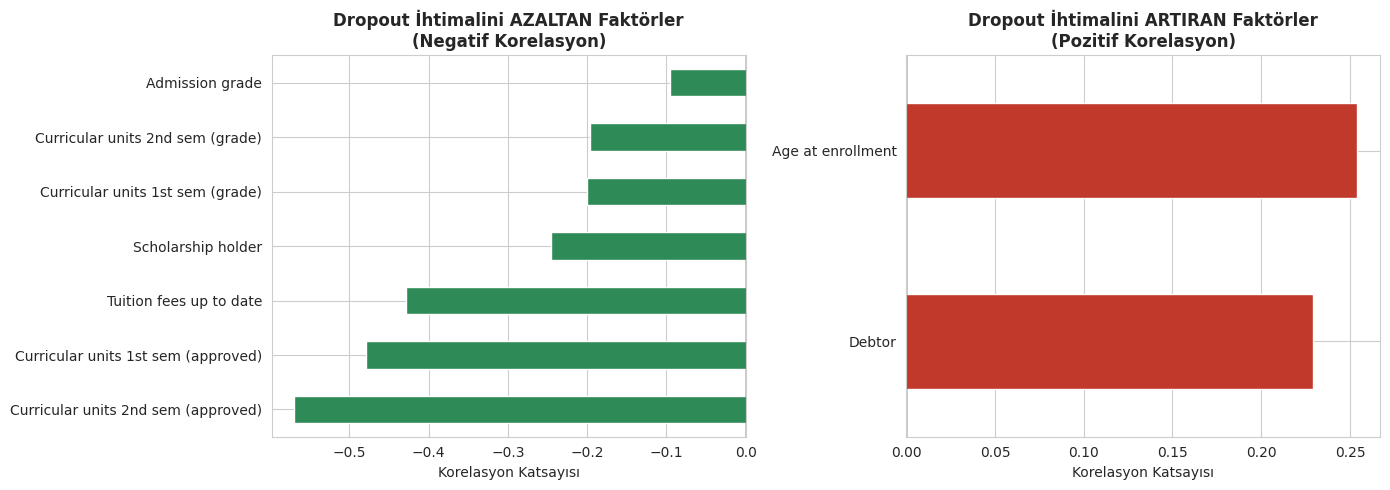

In [13]:
# ── Dropout ile Korelasyon Analizi ───────────────────────────────────
incelenen_degiskenler = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)',
    'Tuition fees up to date',
    'Scholarship holder',
    'Admission grade',
    'Age at enrollment',
    'Debtor',
    'Unemployment rate'
]

df_korr = df_temiz.copy()
df_korr['is_dropout'] = (df_korr['Target'] == 0).astype(int)

for col in df_korr.columns:
    if col != 'Target':
        df_korr[col] = pd.to_numeric(df_korr[col], errors='coerce')
df_korr = df_korr.fillna(df_korr.median(numeric_only=True)).fillna(0)

korelasyonlar = (df_korr[incelenen_degiskenler + ['is_dropout']]
                 .corr()['is_dropout']
                 .drop('is_dropout')
                 .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neg = korelasyonlar[korelasyonlar < 0]
pos = korelasyonlar[korelasyonlar > 0]

neg.plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Dropout İhtimalini AZALTAN Faktörler\n(Negatif Korelasyon)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Korelasyon Katsayısı')
axes[0].axvline(0, color='black', linewidth=1)

pos.plot(kind='barh', ax=axes[1], color='#c0392b')
axes[1].set_title('Dropout İhtimalini ARTIRAN Faktörler\n(Pozitif Korelasyon)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Korelasyon Katsayısı')
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

##Model için Veri Hazırlama

In [14]:
# ── X / y Ayrımı ve Standardizasyon ─────────────────────────────────
X = df_temiz.drop('Target', axis=1)
y = df_temiz['Target']

# Tüm sütunları sayı yapalım
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# boş sütunları bul ve  kaldıralım
tam_bos = X.columns[X.isnull().all()].tolist()
if tam_bos:
    print(f"Tamamen boş sütunlar kaldırıldı: {tam_bos}")
    X = X.drop(columns=tam_bos)

# Kalan NaN'ları sütun medyanıyla dolduralım
X = X.fillna(X.median())

# Hala NaN varsa 0 ile dolduralım
X = X.fillna(0)

print(f"NaN sayısı: {X.isnull().sum().sum()}")  # 0 olmalı

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Özellik matrisi boyutu: {X_scaled.shape}")
print(f"Hedef değişken boyutu : {y.shape}")

Tamamen boş sütunlar kaldırıldı: ['Unemployment rate']
NaN sayısı: 0
Özellik matrisi boyutu: (4424, 26)
Hedef değişken boyutu : (4424,)


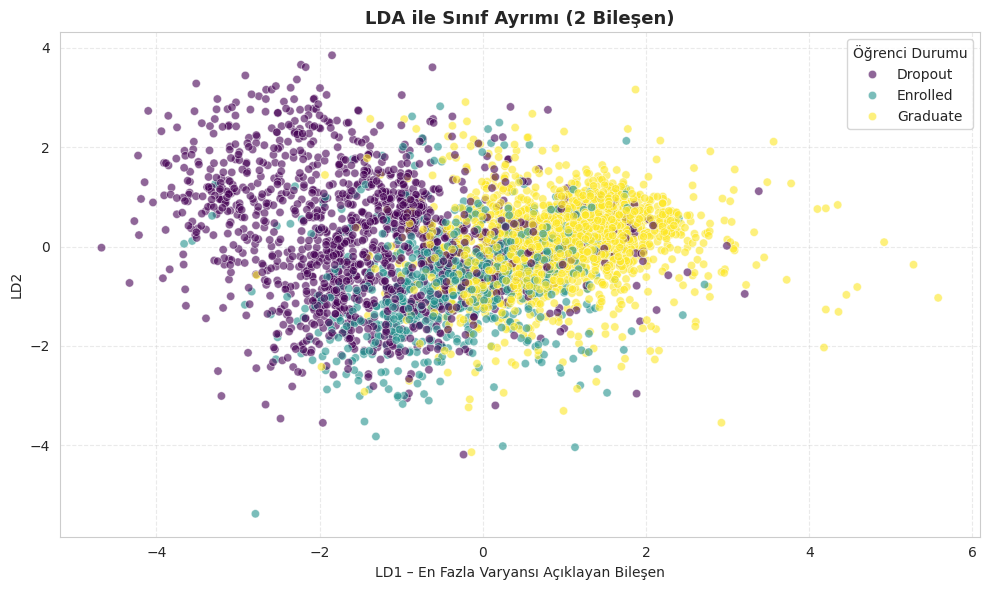

LD1 açıklanan varyans: %91.9
LD2 açıklanan varyans: %8.1


In [15]:
# ── LDA Görselleştirmesi ──────────────────────────────────────────────
lda_viz = LDA(n_components=2)
X_lda = lda_viz.fit_transform(X_scaled, y)

label_map = {0:'Dropout', 1:'Enrolled', 2:'Graduate'}
y_labels = pd.Series(y.values).map(label_map)

renk_paleti = {'Dropout':'#440154', 'Enrolled':'#21918c', 'Graduate':'#fde725'}

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1],
                hue=y_labels, palette=renk_paleti,
                hue_order=['Dropout','Enrolled','Graduate'],
                alpha=0.6, edgecolor='white', linewidth=0.5)

plt.title('LDA ile Sınıf Ayrımı (2 Bileşen)', fontsize=13, fontweight='bold')
plt.xlabel('LD1 – En Fazla Varyansı Açıklayan Bileşen')
plt.ylabel('LD2')
plt.legend(title='Öğrenci Durumu')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

aciklanan_varyas = lda_viz.explained_variance_ratio_
print(f"LD1 açıklanan varyans: %{aciklanan_varyas[0]*100:.1f}")
print(f"LD2 açıklanan varyans: %{aciklanan_varyas[1]*100:.1f}")

In [16]:
# ── Train-Test Bölme ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Eğitim seti : {X_train.shape[0]} gözlem")
print(f"Test seti   : {X_test.shape[0]} gözlem")
print("\nEğitim seti sınıf dağılımı:")
for k, v in sinif_isimleri.items():
    n = (y_train == k).sum()
    print(f"  {v}: {n} ({n/len(y_train)*100:.1f}%)")

Eğitim seti : 3539 gözlem
Test seti   : 885 gözlem

Eğitim seti sınıf dağılımı:
  Dropout: 1137 (32.1%)
  Enrolled: 635 (17.9%)
  Graduate: 1767 (49.9%)


##Model Kurulumu ve Eğitimi

In [17]:
# ── Model ve Hiperparametre Tanımları ────────────────────────────────
# NOT: SVM ve RF parametreleri eğitim süresini dengelemek için daraltılmıştır.
# Daha geniş arama için 'params' dict'leri genişletilebilir.

model_havuzu = {
    'Lojistik Regresyon': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'params': {'C': [0.1, 1, 10]}
    },
    'Karar Ağacı (Budanmış)': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, 15],
            'ccp_alpha': [0.0, 0.001, 0.005]
        }
    },
    'Rastgele Orman': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20]
        }
    },
    'SVM (RBF)': {
        'model': SVC(kernel='rbf', probability=True, random_state=42),
        'params': {'C': [1, 10]}
    },
}

# Naive Bayes tanımlanıyor
nb_model = GaussianNB()



In [19]:
# ── GridSearchCV ile Eğitim ──────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

en_iyi_modeller = {}
cv_sonuclari = {}


for isim, mp in model_havuzu.items():
    grid = GridSearchCV(mp['model'], mp['params'],
                        cv=cv, scoring='accuracy', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    en_iyi_modeller[isim] = grid.best_estimator_
    cv_sonuclari[isim] = {
        'best_params': grid.best_params_,
        'cv_accuracy': grid.best_score_
    }
    print(f"En iyi CV doğruluğu: %{grid.best_score_*100:.2f}  |  Parametreler: {grid.best_params_}")

# Naive Bayes – Cross Validation
nb_cv_scores = cross_val_score(nb_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
nb_model.fit(X_train, y_train)
en_iyi_modeller['Naive Bayes'] = nb_model
cv_sonuclari['Naive Bayes'] = {
    'best_params': 'Yok (parametresiz)',
    'cv_accuracy': nb_cv_scores.mean()
}
print(f"Ortalama CV doğruluğu: %{nb_cv_scores.mean()*100:.2f}  |  Std: {nb_cv_scores.std():.4f}")

print("\n Tüm modeller eğitildi!")

En iyi CV doğruluğu: %74.99  |  Parametreler: {'C': 1}
En iyi CV doğruluğu: %74.37  |  Parametreler: {'ccp_alpha': 0.001, 'max_depth': 10}
En iyi CV doğruluğu: %76.55  |  Parametreler: {'max_depth': 20, 'n_estimators': 100}
En iyi CV doğruluğu: %75.16  |  Parametreler: {'C': 1}
Ortalama CV doğruluğu: %66.94  |  Std: 0.0242

 Tüm modeller eğitildi!


##Model Değerlendirme

In [20]:
# ── Tüm Modellerin Test Seti Sonuçları ────────────────────────────────
sinif_isimleri_liste = ['Dropout', 'Enrolled', 'Graduate']
ozet_sonuclar = []

for isim, model in en_iyi_modeller.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    ozet_sonuclar.append({
        'Model': isim,
        'CV Doğruluğu (%)': round(cv_sonuclari[isim]['cv_accuracy'] * 100, 2),
        'Test Doğruluğu (%)': round(acc * 100, 2),
        'En İyi Parametreler': cv_sonuclari[isim]['best_params']
    })

    print(f"\n{'='*60}")
    print(f"  {isim.upper()}")
    print(f"{'='*60}")
    print(f"  Test Doğruluğu: %{acc*100:.2f}")
    print()
    print(classification_report(y_test, y_pred,
                                target_names=sinif_isimleri_liste))


  LOJISTIK REGRESYON
  Test Doğruluğu: %74.35

              precision    recall  f1-score   support

     Dropout       0.75      0.78      0.77       284
    Enrolled       0.43      0.23      0.30       159
    Graduate       0.79      0.90      0.84       442

    accuracy                           0.74       885
   macro avg       0.66      0.64      0.64       885
weighted avg       0.71      0.74      0.72       885


  KARAR AĞACI (BUDANMIŞ)
  Test Doğruluğu: %74.01

              precision    recall  f1-score   support

     Dropout       0.74      0.73      0.73       284
    Enrolled       0.48      0.29      0.36       159
    Graduate       0.79      0.91      0.85       442

    accuracy                           0.74       885
   macro avg       0.67      0.64      0.65       885
weighted avg       0.72      0.74      0.72       885


  RASTGELE ORMAN
  Test Doğruluğu: %77.40

              precision    recall  f1-score   support

     Dropout       0.80      0.75      

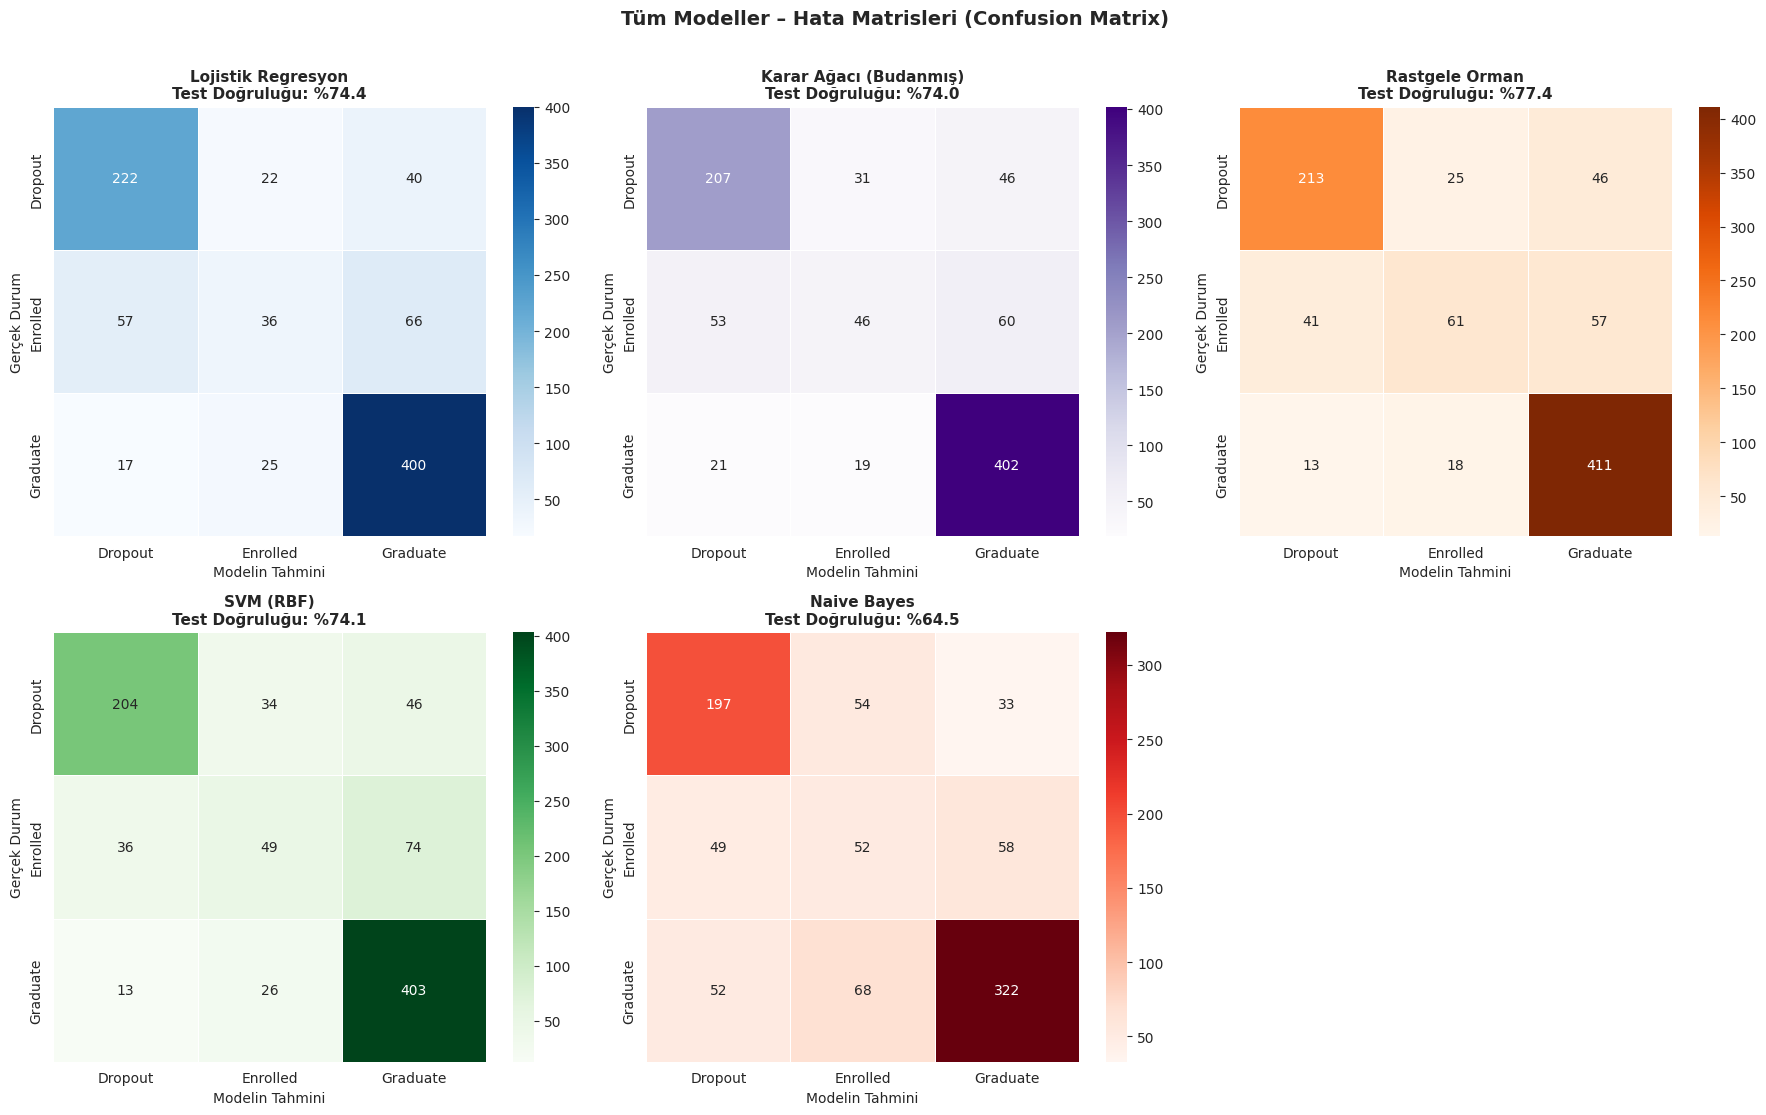

In [21]:
# ── Confusion Matrix Görselleştirmesi ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

renkler = ['Blues', 'Purples', 'Oranges', 'Greens', 'Reds']

for idx, (isim, model) in enumerate(en_iyi_modeller.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=renkler[idx],
                xticklabels=sinif_isimleri_liste,
                yticklabels=sinif_isimleri_liste,
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(f'{isim}\nTest Doğruluğu: %{accuracy_score(y_test,y_pred)*100:.1f}',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Gerçek Durum')
    axes[idx].set_xlabel('Modelin Tahmini')

# Son subplot'u gizleyelim
axes[5].set_visible(False)

plt.suptitle('Tüm Modeller – Hata Matrisleri (Confusion Matrix)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##Model Karşılaştırması

In [22]:
# ── Özet Karşılaştırma Tablosu ──────────────────────────────────────
ozet_df = pd.DataFrame(ozet_sonuclar).sort_values('Test Doğruluğu (%)', ascending=False)
ozet_df = ozet_df.reset_index(drop=True)
ozet_df.index = ozet_df.index + 1  # 1'den başlat
print("\n MODEL KARŞILAŞTIRMA TABLOSU")
print("="*70)
print(ozet_df[['Model','CV Doğruluğu (%)','Test Doğruluğu (%)','En İyi Parametreler']].to_string())
print("="*70)
print(f"\n En iyi model: {ozet_df.iloc[0]['Model']}  "
      f"(Test Doğruluğu: %{ozet_df.iloc[0]['Test Doğruluğu (%)']:.2f})")


 MODEL KARŞILAŞTIRMA TABLOSU
                    Model  CV Doğruluğu (%)  Test Doğruluğu (%)                     En İyi Parametreler
1          Rastgele Orman             76.55               77.40  {'max_depth': 20, 'n_estimators': 100}
2      Lojistik Regresyon             74.99               74.35                                {'C': 1}
3               SVM (RBF)             75.16               74.12                                {'C': 1}
4  Karar Ağacı (Budanmış)             74.37               74.01   {'ccp_alpha': 0.001, 'max_depth': 10}
5             Naive Bayes             66.94               64.52                      Yok (parametresiz)

 En iyi model: Rastgele Orman  (Test Doğruluğu: %77.40)


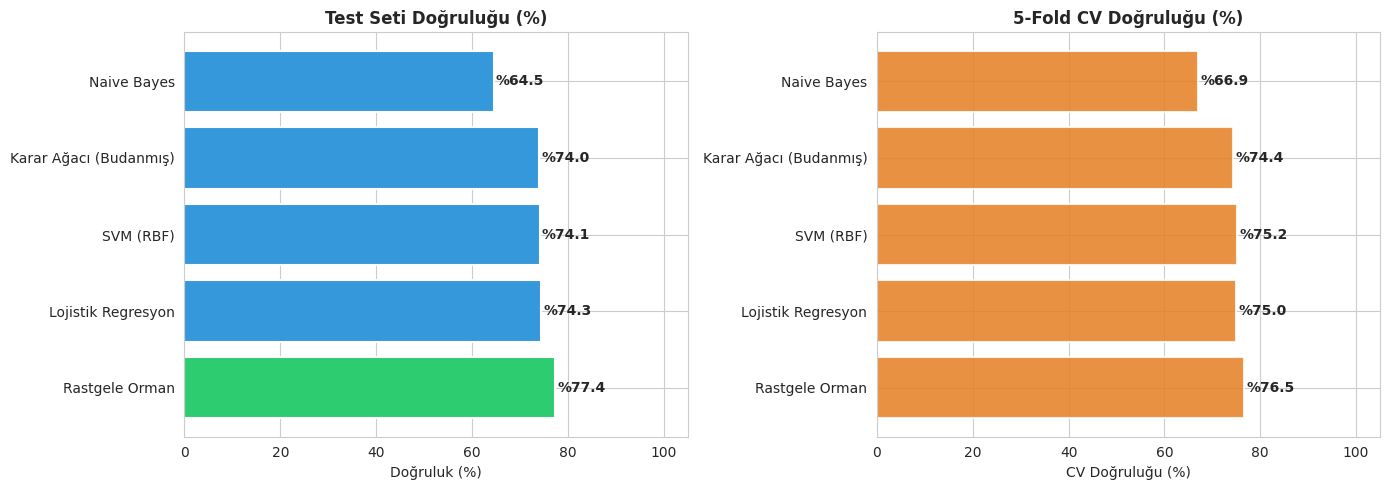

In [23]:
# ── Doğruluk Karşılaştırma Grafikleri ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

renkler_bar = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(ozet_df))]

# Test Doğruluğu
bars = axes[0].barh(ozet_df['Model'], ozet_df['Test Doğruluğu (%)'],
                     color=renkler_bar, edgecolor='white', linewidth=1.5)
axes[0].set_title('Test Seti Doğruluğu (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Doğruluk (%)')
axes[0].set_xlim(0, 105)
for bar, val in zip(bars, ozet_df['Test Doğruluğu (%)']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'%{val:.1f}', va='center', fontweight='bold')

# CV Doğruluğu
bars2 = axes[1].barh(ozet_df['Model'], ozet_df['CV Doğruluğu (%)'],
                      color='#e67e22', edgecolor='white', linewidth=1.5, alpha=0.85)
axes[1].set_title('5-Fold CV Doğruluğu (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CV Doğruluğu (%)')
axes[1].set_xlim(0, 105)
for bar, val in zip(bars2, ozet_df['CV Doğruluğu (%)']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'%{val:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

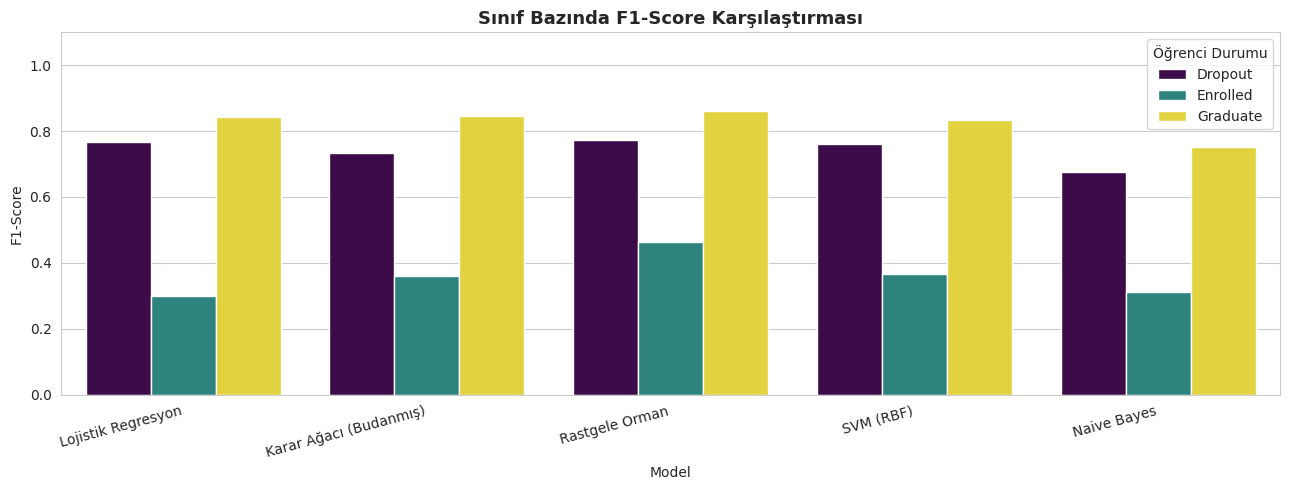

In [24]:
# ── Sınıf Bazında F1-Score Karşılaştırması ───────────────────────────
from sklearn.metrics import f1_score

f1_verisi = []
for isim, model in en_iyi_modeller.items():
    y_pred = model.predict(X_test)
    f1_scores = f1_score(y_test, y_pred, average=None)
    for sinif_idx, sinif_adi in enumerate(sinif_isimleri_liste):
        f1_verisi.append({
            'Model': isim,
            'Sınıf': sinif_adi,
            'F1-Score': round(f1_scores[sinif_idx], 3)
        })

f1_df = pd.DataFrame(f1_verisi)

plt.figure(figsize=(13, 5))
sns.barplot(data=f1_df, x='Model', y='F1-Score', hue='Sınıf',
            palette={'Dropout':'#440154','Enrolled':'#21918c','Graduate':'#fde725'})
plt.title('Sınıf Bazında F1-Score Karşılaştırması', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.legend(title='Öğrenci Durumu')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

##Öznitelik Önemi (En İyi Model: Rastgele Orman)

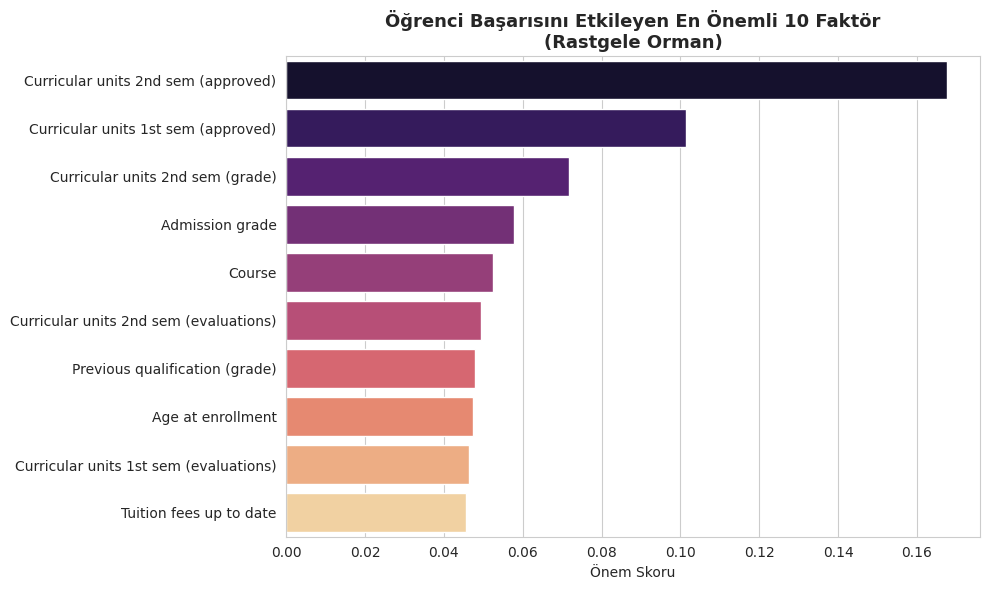


İlk 10 Değişken:
                              Değişken     Önem
   Curricular units 2nd sem (approved) 0.167600
   Curricular units 1st sem (approved) 0.101457
      Curricular units 2nd sem (grade) 0.071734
                       Admission grade 0.057651
                                Course 0.052429
Curricular units 2nd sem (evaluations) 0.049425
        Previous qualification (grade) 0.047952
                     Age at enrollment 0.047444
Curricular units 1st sem (evaluations) 0.046429
               Tuition fees up to date 0.045546


In [25]:
# ── Random Forest Öznitelik Önemi ────────────────────────────────────
rf_model = en_iyi_modeller['Rastgele Orman']

importances = rf_model.feature_importances_
feature_names = X.columns

ozellik_df = (pd.DataFrame({'Değişken': feature_names, 'Önem': importances})
              .sort_values('Önem', ascending=False)
              .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=ozellik_df, x='Önem', y='Değişken',
            palette='magma')
plt.title('Öğrenci Başarısını Etkileyen En Önemli 10 Faktör\n(Rastgele Orman)',
          fontsize=13, fontweight='bold')
plt.xlabel('Önem Skoru')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\nİlk 10 Değişken:")
print(ozellik_df.to_string(index=False))

In [26]:
print(f"Test Doğruluğu: %{accuracy_score(y_test_b, y_pred_b)*100:.2f}")
print()
print(classification_report(y_test_b, y_pred_b, target_names=['Dropout', 'Graduate']))

NameError: name 'y_test_b' is not defined